# Эксперименты

Качество сравнивал по среднему максимальной precision при recall не ниже 0.70 на двух временных разбиениях, `fold_a` и `fold_b`. Вариант оставлял, если среднее росло и ни одно разбиение не ухудшалось. Прогоны записаны в локальный MLflow, результаты в `results/experiments.csv`

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

import scripts
import tracking
from bot_detection_challenge.metric import pr_curve

plt.rcParams.update({'figure.figsize': (11, 3.4), 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False})
meta = scripts.read_meta()
window = scripts.window_events(scripts.read_events(), meta)
clean = scripts.clean_events(window)
folds = scripts.fold_cookies(meta)
labels = scripts.indexed_by_cookie(meta)[['target', 'window_start_ts']]
frame = scripts.model_features(clean, meta).join(labels)
groups = scripts.slice_groups(scripts.cookie_features(clean, meta), meta)
raw_frame = scripts.quickstart_features(window, meta).join(labels)
print('cookie:', len(frame), '| признаков:', len(scripts.MODEL_FEATURES))
print('в проверке ботов и их доля:',
      {fold: (int(frame.loc[parts['valid'], 'target'].sum()),
              round(frame.loc[parts['valid'], 'target'].mean(), 4))
       for fold, parts in folds.items()},
      '| доля по всей исследовательской части:', round(frame['target'].mean(), 4))

cookie: 16000 | признаков: 62
в проверке ботов и их доля: {'fold_a': (228, np.float64(0.0869)), 'fold_b': (248, np.float64(0.0773))} | доля по всей исследовательской части: 0.0809


Таблица признаков считается один раз по очищенным событиям окна, каждый вариант берёт из неё свои столбцы. Метки 04-17..04-19 закрыты в `read_meta`, эти дни не участвуют ни в обучении, ни в проверке

In [2]:
RUNS = {}
FOREST = {'n_estimators': 300, 'min_samples_leaf': 3, 'random_state': 0}
CATBOOST = {'iterations': 800, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3}
PARAM_KEYS = ('n_estimators', 'min_samples_leaf', 'iterations', 'depth', 'learning_rate',
              'l2_leaf_reg', 'max_iter', 'max_leaf_nodes', 'l2_regularization',
              'early_stopping')
SEED_KEYS = ('random_seed', 'random_state')


def family_columns(*families):
    """Столбцы перечисленных семейств признаков, объём входит всегда"""
    return [name for family in ('объём',) + families
            for name in scripts.FEATURE_FAMILIES[family]]


def model_seeds(estimators):
    """Seed каждой модели: у CatBoost он зовётся random_seed, у остальных random_state"""
    values = []
    for _, part in estimators:
        settings = part.get_params()
        values += [str(settings[key]) for key in SEED_KEYS if key in settings]
    return ','.join(values)


def model_params(make_model):
    """Класс модели, её параметры, seed всех моделей и число усредняемых моделей"""
    model = make_model()
    # У усреднения по seed модели лежат в estimators, у одиночной модели список из неё самой
    estimators = getattr(model, 'estimators', None) or [('one', model)]
    inner = estimators[0][1]
    settings = {key: value for key, value in inner.get_params().items() if key in PARAM_KEYS}
    return {'model': type(inner).__name__, 'n_models': len(estimators),
            'seeds': model_seeds(estimators)} | settings


def experiment(name, change, features, make_model, data=None, weights=None, weight_scheme=''):
    """Обучает вариант на двух разбиениях, пишет прогон в MLflow и запоминает результат"""
    data = frame if data is None else data
    predictions, timings = scripts.run_folds(make_model, data, features, folds, weights)
    table, mean = scripts.evaluate_folds(predictions, meta, folds)
    settings = model_params(make_model) | {'weight_scheme': weight_scheme or 'нет'}
    run_id = tracking.log_experiment(
        name, change, {'features': features, 'params': settings},
        {'table': table, 'mean': mean, 'predictions': predictions, 'timings': timings,
         'slices': scripts.evaluate_slices(predictions, meta, groups),
         'folds': folds, 'meta': meta})
    RUNS[name] = {'mean': mean, 'table': table, 'predictions': predictions, 'run_id': run_id}
    return RUNS[name]


def show(name, other=None):
    """Печатает метрики варианта, разницу с вариантом сравнения и отмечает его в прогоне"""
    values = RUNS[name]['table']['precision_at_recall_070']
    delta = '' if other is None else f' ({RUNS[name]["mean"] - RUNS[other]["mean"]:+.4f})'
    if other is not None:
        tracking.set_base(RUNS[name]['run_id'], RUNS[other]['run_id'])
    print(f'{name:26s} fold_a {values["fold_a"]:.4f} | fold_b {values["fold_b"]:.4f} '
          f'| среднее {RUNS[name]["mean"]:.4f}{delta}')

## База: алгоритм quickstart

Два счётчика, число событий окна и число разных объявлений, в случайном лесу с теми же параметрами, что в quickstart. Сравнил два варианта: исходные события окна и те же события после удаления полных дублей. Дубли удалены по результатам разведочного анализа

In [3]:
base = ['n_events', 'item_nunique']
experiment('quickstart__raw', 'два счётчика quickstart на событиях окна', base,
           lambda: RandomForestClassifier(**FOREST), data=raw_frame)
experiment('quickstart__clean', 'те же счётчики на очищенных событиях', family_columns(),
           lambda: RandomForestClassifier(**FOREST))
show('quickstart__raw')
show('quickstart__clean', 'quickstart__raw')

quickstart__raw            fold_a 0.1035 | fold_b 0.0954 | среднее 0.0995
quickstart__clean          fold_a 0.1021 | fold_b 0.0921 | среднее 0.0971 (-0.0023)


База дала 0.0995 при доле ботов 0.0869 и 0.0773 в проверочных частях. После удаления дублей среднее снизилось на 0.0023, до 0.0971. Для следующих опытов оставил очищенные события: полные дубли добавляют нулевые интервалы

## Гипотеза 1: состав действий и разнообразие

Боты чаще открывают выдачу и объявления и реже листают фото, а глубина выдачи и число локаций в разведочном анализе дали одномерные AUC 0.723 и 0.715. Добавил счётчики и доли девяти типов событий, затем разнообразие объявлений, категорий, локаций и запросов вместе с глубиной выдачи

In [4]:
experiment('forest__composition', 'счётчики и доли девяти типов событий',
           family_columns('состав действий'), lambda: RandomForestClassifier(**FOREST))
experiment('forest__diversity', 'разнообразие объектов и глубина выдачи',
           family_columns('разнообразие'), lambda: RandomForestClassifier(**FOREST))
show('forest__composition', 'quickstart__clean')
show('forest__diversity', 'quickstart__clean')

forest__composition        fold_a 0.1616 | fold_b 0.1645 | среднее 0.1631 (+0.0659)
forest__diversity          fold_a 0.2005 | fold_b 0.2237 | среднее 0.2121 (+0.1150)


Состав действий дал 0.1631, разнообразие 0.2121. Оба варианта улучшили результат на обоих разбиениях

## Гипотеза 2: ритм

У ботов короче медианный интервал между событиями и выше пик событий за минуту, AUC 0.271 и 0.698. Добавил интервалы, их разброс, долю секундных интервалов, длительность активности и пик за минуту

In [5]:
experiment('forest__rhythm', 'интервалы между событиями и пик за минуту', family_columns('ритм'),
           lambda: RandomForestClassifier(**FOREST))
show('forest__rhythm', 'quickstart__clean')

forest__rhythm             fold_a 0.2287 | fold_b 0.2475 | среднее 0.2381 (+0.1410)


Ритм добавил 0.1410 к среднему базы, больше остальных семейств по отдельности

## Гипотеза 3: возраст и клиент

Cookie моложе недели примерно втрое чаще боты, headless-браузеры дают 27.7% ботов против 0.0809 во всей исследовательской части. Возраст cookie и вид клиента добавил по отдельности: возраст считается по метаданным, вид клиента по фиксированному словарю строк User-Agent

In [6]:
technical = groups['ua_kind'].isin(['headless', 'http_lib']) & (frame['target'] == 1)
print('ботов у headless и HTTP-библиотек:', int(technical.sum()),
      'из', int(frame['target'].sum()))
experiment('forest__age', 'возраст cookie на начало окна', family_columns('возраст'),
           lambda: RandomForestClassifier(**FOREST))
experiment('forest__client', 'платформа, вид клиента и число строк User-Agent',
           family_columns('клиент'), lambda: RandomForestClassifier(**FOREST))
show('forest__age', 'quickstart__clean')
show('forest__client', 'quickstart__clean')

ботов у headless и HTTP-библиотек: 101 из 739


forest__age                fold_a 0.1321 | fold_b 0.1070 | среднее 0.1196 (+0.0225)
forest__client             fold_a 0.1159 | fold_b 0.1021 | среднее 0.1090 (+0.0119)


Возраст добавил 0.0225, клиент 0.0119. Это самые слабые семейства: у headless и HTTP-библиотек высокая доля ботов, но покрывают они только 101 бота из 739, остальные ходят с обычным браузером или из приложения

## Гипотеза 4: курсор

Разброс координат курсора разделяет классы сильнее всех одиночных признаков, AUC 0.060 по x, но координаты есть только у web-cookie. Добавил долю событий с координатами и разброс по осям, у мобильных cookie эти значения остаются пропусками

In [7]:
experiment('forest__pointer', 'доля событий с курсором и разброс координат',
           family_columns('курсор'), lambda: RandomForestClassifier(**FOREST))
show('forest__pointer', 'quickstart__clean')

forest__pointer            fold_a 0.2070 | fold_b 0.1982 | среднее 0.2026 (+0.1055)


Плюс 0.1055 при трёх столбцах, определённых меньше чем у половины cookie

## Гипотеза 5: шесть семейств вместе

Каждое семейство добавляло сигнал по отдельности. Собрал их в один набор из 47 признаков на том же лесу

In [8]:
EDA_FAMILIES = ('состав действий', 'разнообразие', 'ритм', 'возраст', 'клиент', 'курсор')
experiment('forest__all-families', 'все шесть семейств разведочного анализа',
           family_columns(*EDA_FAMILIES), lambda: RandomForestClassifier(**FOREST))
show('forest__all-families', 'quickstart__clean')

forest__all-families       fold_a 0.6250 | fold_b 0.5819 | среднее 0.6035 (+0.5064)


Все шесть семейств вместе дали 0.6035 против 0.0971 у базы на тех же событиях и превысили результат каждого семейства по отдельности

## Гипотеза 6: градиентный бустинг вместо леса

На наборе из 47 признаков сравнил случайный лес, CatBoost и HistGradientBoosting

In [9]:
HGB = {'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 31, 'min_samples_leaf': 20,
       'l2_regularization': 1.0}
experiment('catboost__depth6', 'CatBoost глубины 6, 800 итераций', family_columns(*EDA_FAMILIES),
           lambda: scripts.catboost_model(CATBOOST, 0))
experiment('hgb__slow', 'HistGradientBoosting, 600 итераций', family_columns(*EDA_FAMILIES),
           lambda: HistGradientBoostingClassifier(**HGB, early_stopping=False, random_state=0))
show('catboost__depth6', 'forest__all-families')
show('hgb__slow', 'forest__all-families')

catboost__depth6           fold_a 0.7407 | fold_b 0.6544 | среднее 0.6976 (+0.0941)
hgb__slow                  fold_a 0.6452 | fold_b 0.6327 | среднее 0.6389 (+0.0355)


CatBoost поднял среднее до 0.6976, HistGradientBoosting до 0.6389 на тех же признаках. Оставил CatBoost

## Гипотеза 7: настройки бустинга

По отдельности увеличил число итераций, глубину деревьев и l2

In [10]:
variants = {
    'catboost__iter1500': {**CATBOOST, 'iterations': 1500},
    'catboost__depth8': {**CATBOOST, 'depth': 8},
    'catboost__l2-10': {**CATBOOST, 'l2_leaf_reg': 10},
}
for name, params in variants.items():
    experiment(name, f'CatBoost {params}', family_columns(*EDA_FAMILIES),
               lambda params=params: scripts.catboost_model(params, 0))
show('catboost__depth6')
for name in variants:
    show(name, 'catboost__depth6')

catboost__depth6           fold_a 0.7407 | fold_b 0.6544 | среднее 0.6976
catboost__iter1500         fold_a 0.7080 | fold_b 0.6374 | среднее 0.6727 (-0.0249)
catboost__depth8           fold_a 0.7143 | fold_b 0.6421 | среднее 0.6782 (-0.0194)
catboost__l2-10            fold_a 0.6880 | fold_b 0.6541 | среднее 0.6711 (-0.0265)


Все три настройки хуже: 1500 итераций на 0.0249, глубина 8 на 0.0194, l2 10 на 0.0265. Оставил 800 итераций, глубину 6 и l2 3

## Гипотеза 8: курсор подробнее

Курсор оказался сильным сигналом, но в наборе от него только три столбца. Добавил положение курсора на краю экрана, шаг между соседними координатами, число точек, отсутствие координат на web и нормированный размах

In [11]:
CURSOR_FAMILIES = EDA_FAMILIES + ('курсор на краю', 'разброс курсора')
experiment('catboost__cursor', 'край экрана, шаг между координатами и размах',
           family_columns(*CURSOR_FAMILIES), lambda: scripts.catboost_model(CATBOOST, 0))
show('catboost__depth6')
show('catboost__cursor', 'catboost__depth6')

catboost__depth6           fold_a 0.7407 | fold_b 0.6544 | среднее 0.6976
catboost__cursor           fold_a 0.7692 | fold_b 0.7016 | среднее 0.7354 (+0.0378)


Плюс 0.0378, выросли оба разбиения. Больше всего прибавил fold_b, где курсорных cookie больше

## Гипотеза 9: разброс по seed

Все сравнения до сих пор шли на seed 0, а разницы последних гипотез измеряются сотыми. Повторил ту же конфигурацию с seed 17 и 42

In [12]:
for seed in (17, 42):
    experiment(f'catboost__seed{seed}', f'та же конфигурация с seed {seed}',
               family_columns(*CURSOR_FAMILIES),
               lambda seed=seed: scripts.catboost_model(CATBOOST, seed))
experiment('catboost__cursor-800-l2-3', 'среднее вероятностей по seed 0, 17 и 42',
           family_columns(*CURSOR_FAMILIES), lambda: scripts.seed_average(CATBOOST))
show('catboost__cursor')
for name in ('catboost__seed17', 'catboost__seed42', 'catboost__cursor-800-l2-3'):
    show(name, 'catboost__cursor')

catboost__cursor           fold_a 0.7692 | fold_b 0.7016 | среднее 0.7354
catboost__seed17           fold_a 0.7656 | fold_b 0.6566 | среднее 0.7111 (-0.0243)
catboost__seed42           fold_a 0.8000 | fold_b 0.6705 | среднее 0.7352 (-0.0002)
catboost__cursor-800-l2-3  fold_a 0.7788 | fold_b 0.6797 | среднее 0.7293 (-0.0062)


Среднее на seed 0, 17 и 42 составило 0.7354, 0.7111 и 0.7352. Разброс 0.024 сопоставим с разницами 0.0194-0.0265 из гипотезы 7. Для следующих сравнений усреднил вероятности трёх моделей и пересчитал базовый вариант тем же способом, его среднее 0.7293

## Гипотеза 10: география, длина обучения и регуляризация

В разборе ошибок у пропущенных ботов было около пяти локаций на категорию против двух у пойманных и не было главного города. Добавил локации на категорию, долю главного города и доли смен локации и категории подряд. По одному число итераций и регуляризация уже давали противоречивые результаты, поэтому проверил их вместе с географией сеткой: два набора признаков, 800 и 1500 итераций, l2 3 и 10. Для сравнения взял прежний набор из 58 признаков: 800 итераций, l2 3, усреднение seed 0, 17 и 42

In [13]:
GEO_FAMILIES = CURSOR_FAMILIES + ('география',)
grid = itertools.product((CURSOR_FAMILIES, GEO_FAMILIES), (800, 1500), (3, 10))
for families, iterations, l2 in grid:
    params = {**CATBOOST, 'iterations': iterations, 'l2_leaf_reg': l2}
    geo = 'география' in families
    name = f"catboost__{'geo' if geo else 'cursor'}-{iterations}-l2-{l2}"
    if name not in RUNS:
        experiment(name, f"{'с географией' if geo else 'без географии'}, {iterations} итераций, "
                   f'l2 {l2}', family_columns(*families),
                   lambda params=params: scripts.seed_average(params))
    values = RUNS[name]['table']['precision_at_recall_070']
    print(f"{'62' if geo else '58'} признака | {iterations} итераций | l2 {l2:2d} | "
          f"fold_a {values['fold_a']:.4f} | fold_b {values['fold_b']:.4f} "
          f"| среднее {RUNS[name]['mean']:.4f}")

58 признака | 800 итераций | l2  3 | fold_a 0.7788 | fold_b 0.6797 | среднее 0.7293


58 признака | 800 итераций | l2 10 | fold_a 0.7143 | fold_b 0.6705 | среднее 0.6924


58 признака | 1500 итераций | l2  3 | fold_a 0.7431 | fold_b 0.6797 | среднее 0.7114


58 признака | 1500 итераций | l2 10 | fold_a 0.7729 | fold_b 0.7056 | среднее 0.7393


62 признака | 800 итераций | l2  3 | fold_a 0.7778 | fold_b 0.6824 | среднее 0.7301


62 признака | 800 итераций | l2 10 | fold_a 0.7892 | fold_b 0.6988 | среднее 0.7440


62 признака | 1500 итераций | l2  3 | fold_a 0.7547 | fold_b 0.7016 | среднее 0.7282


62 признака | 1500 итераций | l2 10 | fold_a 0.7960 | fold_b 0.7131 | среднее 0.7546


Без географии переход с 800 на 1500 итераций снизил среднее при l2 3 с 0.7293 до 0.7114, но повысил при l2 10 с 0.6924 до 0.7393. Лучший результат сетки, 0.7546, получился с географией, 1500 итерациями и l2 10

In [14]:
FINAL = 'catboost__geo-1500-l2-10'
show('catboost__cursor-800-l2-3')
show(FINAL, 'catboost__cursor-800-l2-3')

catboost__cursor-800-l2-3  fold_a 0.7788 | fold_b 0.6797 | среднее 0.7293
catboost__geo-1500-l2-10   fold_a 0.7960 | fold_b 0.7131 | среднее 0.7546 (+0.0253)


Плюс 0.0253 к набору из 58 признаков, оба разбиения выросли. Выбрал этот вариант: 62 признака, 1500 итераций, l2 10 и усреднение seed 0, 17 и 42

В следующих девяти проверках сравнивал каждый вариант с этой моделью: 0.7960 на `fold_a`, 0.7131 на `fold_b`. Модель для сравнения не менял до конца серии

## Гипотеза 11: локальный ритм

Общий разброс интервалов считается по всему окну и смешивает короткие серии с многочасовыми паузами. Взял интервалы между соседними уникальными моментами времени от 1 до 1800 секунд и описал их форму: число интервалов, отклонение от медианы, отношение квантилей и нормированную энтропию, отдельно по всем событиям и по просмотрам объявлений. Рядом контроль: два уже существующих признака ровности и минимального интервала

In [15]:
LOCAL_GAP_MIN, LOCAL_GAP_MAX, SHAPE_MIN_COUNT = 1, 1800, 5


def local_gaps(events):
    """Интервалы между соседними уникальными моментами времени, только от 1 до 1800 секунд"""
    points = events[['cookie_id', 'event_ts']].drop_duplicates()
    points = points.sort_values(['cookie_id', 'event_ts'])
    gap = points['event_ts'].groupby(points['cookie_id']).diff().dt.total_seconds()
    # Длинные паузы выбрасываются как интервалы, соседние точки заново не сшиваются
    usable = gap.between(LOCAL_GAP_MIN, LOCAL_GAP_MAX)
    return pd.DataFrame({'cookie_id': points.loc[usable, 'cookie_id'], 'gap': gap[usable]})


def gap_shape(gaps, cookies, prefix):
    """Число интервалов, отклонение от медианы, отношение квантилей и энтропия длительностей"""
    cookie, gap = gaps['cookie_id'], gaps['gap']
    grouped = gap.groupby(cookie)
    median = grouped.median()
    deviation = (gap - cookie.map(median)).abs().groupby(cookie).median()
    share = gap / cookie.map(grouped.sum())
    entropy = (-share * np.log(share)).groupby(cookie).sum() / np.log(grouped.size())
    shape = pd.DataFrame({
        f'{prefix}_mad_rel': deviation / median,
        f'{prefix}_q90_q10': grouped.quantile(0.9) / grouped.quantile(0.1),
        f'{prefix}_entropy': entropy,
    })
    # Форма определена от пяти интервалов, само число интервалов без них равно нулю
    out = shape.where(grouped.size() >= SHAPE_MIN_COUNT).reindex(cookies)
    out.insert(0, f'{prefix}_n', grouped.size().reindex(cookies, fill_value=0).astype(int))
    return out


def rhythm_extra(events, cookies):
    """Ровность интервалов и минимальный интервал к медианному по всем событиям окна"""
    gap = events['event_ts'].groupby(events['cookie_id']).diff().dt.total_seconds()
    gaps = gap.groupby(events['cookie_id'])
    deviation = (gap - gaps.transform('median')).abs().groupby(events['cookie_id']).median()
    median = gaps.median().replace(0, np.nan)
    return pd.DataFrame({
        'gap_mad_rel': (deviation / median).where(gaps.count() >= 3),
        'gap_min_over_median': (gaps.min() / median).where(gaps.count() >= 2),
    }).reindex(cookies)


views = clean[clean['event_name'] == 'item_view']
local = gap_shape(local_gaps(clean), frame.index, 'local_gap').join(
    gap_shape(local_gaps(views), frame.index, 'view_gap'))
with_rhythm = frame.join(local).join(rhythm_extra(clean, frame.index))
experiment('catboost__rhythm-simple', 'два существующих признака ровности и минимума',
           family_columns(*GEO_FAMILIES) + ['gap_mad_rel', 'gap_min_over_median'],
           lambda: scripts.seed_average(scripts.FINAL_PARAMS), data=with_rhythm)
experiment('catboost__local-rhythm', 'форма коротких интервалов по двум потокам событий',
           family_columns(*GEO_FAMILIES) + list(local.columns),
           lambda: scripts.seed_average(scripts.FINAL_PARAMS), data=with_rhythm)
show('catboost__rhythm-simple', FINAL)
show('catboost__local-rhythm', FINAL)

catboost__rhythm-simple    fold_a 0.7960 | fold_b 0.6350 | среднее 0.7155 (-0.0390)
catboost__local-rhythm     fold_a 0.7970 | fold_b 0.6960 | среднее 0.7465 (-0.0081)


Два простых признака снизили `fold_b` на 0.078. Набор статистик коротких интервалов снизил среднее на 0.0081. В итоговый набор их не добавил

## Гипотеза 12: связь поиска с просмотром

Сопоставил каждый просмотр с последним поиском строго раньше него и не старше 600 секунд, взял его категорию и локацию и посчитал долю несовпадений. Рядом доля просмотров без недавнего поиска и доля поисков, за которыми просмотр случился не позже 60 секунд. Если на одном моменте времени несколько поисков с разным контекстом, поле считается неопределённым, поэтому порядок строк на результат не влияет

In [16]:
CONTEXT_S, RESPONSE_S = 600, 60
CONTEXT_FIELDS = {'item_category': 'search_category', 'item_location': 'search_location'}


def search_context(searches):
    """Контекст поисков одного момента времени: значение, если оно одно и известно"""
    grouped = searches.groupby(['cookie_id', 'event_ts'])
    context = pd.DataFrame(index=grouped.size().index)
    for field, name in CONTEXT_FIELDS.items():
        context[name] = grouped[field].first().where(grouped[field].nunique(dropna=False) == 1)
    return context.reset_index().rename(columns={'event_ts': 'search_ts'})


def search_response(searches, views):
    """Доля поисков, за которыми есть просмотр строго позже и не позже 60 секунд"""
    moments = views[['cookie_id', 'event_ts']].drop_duplicates().sort_values('event_ts')
    linked = pd.merge_asof(searches[['cookie_id', 'event_ts']].sort_values('event_ts'),
                           moments.rename(columns={'event_ts': 'view_ts'}),
                           left_on='event_ts', right_on='view_ts', by='cookie_id',
                           direction='forward', allow_exact_matches=False,
                           tolerance=pd.Timedelta(seconds=RESPONSE_S))
    return linked['view_ts'].notna().groupby(linked['cookie_id']).mean()


def search_view_features(events, cookies):
    """Совпадение просмотра с последним поиском и отклик просмотром на поиск"""
    searches = events[events['event_name'] == 'search_results_view']
    views = events[events['event_name'] == 'item_view']
    linked = pd.merge_asof(views.sort_values('event_ts'),
                           search_context(searches).sort_values('search_ts'),
                           left_on='event_ts', right_on='search_ts', by='cookie_id',
                           direction='backward', allow_exact_matches=False,
                           tolerance=pd.Timedelta(seconds=CONTEXT_S))
    cookie = linked['cookie_id']
    known = {field: linked[field].notna() & linked[name].notna()
             for field, name in CONTEXT_FIELDS.items()}
    out = pd.DataFrame({
        'view_cat_mismatch': scripts.share_of(
            known['item_category'] & (linked['item_category'] != linked['search_category']),
            known['item_category'], cookie),
        'view_loc_mismatch': scripts.share_of(
            known['item_location'] & (linked['item_location'] != linked['search_location']),
            known['item_location'], cookie),
        'view_without_search': linked['search_ts'].isna().groupby(cookie).mean(),
        'view_with_context_n': (known['item_category'] | known['item_location']).groupby(
            cookie).sum(),
        'search_response': search_response(searches, views),
    }).reindex(cookies)
    out['view_with_context_n'] = out['view_with_context_n'].fillna(0).astype(int)
    return out


links = search_view_features(clean, frame.index)
with_links = with_rhythm.join(links)
experiment('catboost__search-links', 'связь просмотра с последним поиском и отклик на поиск',
           family_columns(*GEO_FAMILIES) + list(links.columns),
           lambda: scripts.seed_average(scripts.FINAL_PARAMS), data=with_links)
experiment('catboost__rhythm-links', 'локальный ритм и связь поиска вместе',
           family_columns(*GEO_FAMILIES) + list(local.columns) + list(links.columns),
           lambda: scripts.seed_average(scripts.FINAL_PARAMS), data=with_links)
show('catboost__search-links', FINAL)
show('catboost__rhythm-links', FINAL)

catboost__search-links     fold_a 0.7799 | fold_b 0.6836 | среднее 0.7317 (-0.0228)
catboost__rhythm-links     fold_a 0.7740 | fold_b 0.6517 | среднее 0.7129 (-0.0417)


Связь поиска с просмотром снизила среднее на 0.0228, вместе с локальным ритмом на 0.0417. Эти признаки в финал не включил

## Гипотеза 13: вес android

На android приходится около трети ботов и половина пропусков. Дал строкам android вес 1.5 одинаково для обоих классов, вес нормируется внутри обучающей части каждого разбиения, проверка и метрики остаются без весов

In [17]:
platform = scripts.cookie_features(clean, meta)['platform']
android_weights = pd.Series(np.where(platform == 'android', 1.5, 1.0), index=frame.index)
experiment('catboost__android-weight', 'вес 1.5 строкам android для обоих классов',
           family_columns(*GEO_FAMILIES), lambda: scripts.seed_average(scripts.FINAL_PARAMS),
           weights=android_weights, weight_scheme='android 1.5, остальные 1')
show(FINAL)
show('catboost__android-weight', FINAL)

catboost__geo-1500-l2-10   fold_a 0.7960 | fold_b 0.7131 | среднее 0.7546
catboost__android-weight   fold_a 0.7892 | fold_b 0.7114 | среднее 0.7503 (-0.0043)


Среднее снизилось на 0.0043, оба разбиения стали хуже. Оставил обучение без весов

## Гипотеза 14: порядок одновременных событий

У части cookie несколько событий приходится на одну секунду, и четыре признака финала зависят от того, в каком порядке они лежат в файле: шаги курсора и доли смен локации и категории. Заменил их версиями по группам одинакового времени: для координат в одной секунде взял медиану, для смен посчитал ожидаемую долю по распределениям соседних групп

In [18]:
def group_pointer_steps(events, cookies):
    """Шаги курсора между моментами времени: внутри момента берётся медиана координат"""
    with_pair = ((events['platform_norm'] == 'web') & events['pointer_x'].notna()
                 & events['pointer_y'].notna())
    points = events.loc[with_pair, ['cookie_id', 'event_ts', 'pointer_x', 'pointer_y']]
    centers = points.groupby(['cookie_id', 'event_ts'])[['pointer_x', 'pointer_y']].median()
    centers = centers.reset_index().sort_values(['cookie_id', 'event_ts'])
    moved = centers.groupby('cookie_id')[['pointer_x', 'pointer_y']].diff()
    steps = np.sqrt(moved['pointer_x'] ** 2 + moved['pointer_y'] ** 2).groupby(
        centers['cookie_id'])
    return pd.DataFrame({'pointer_step_mean_t': steps.mean(),
                         'pointer_step_median_t': steps.median()}).reindex(cookies)


def expected_switch_share(events, field, cookies):
    """Ожидаемая доля смен значения между соседними группами одинакового времени"""
    rank = events.groupby('cookie_id')['event_ts'].rank(method='dense')
    known = pd.DataFrame({'cookie_id': events['cookie_id'], 'rank': rank,
                          'value': events[field]}).dropna(subset=['value'])
    counts = known.groupby(['cookie_id', 'rank', 'value']).size().rename('n').reset_index()
    counts['p'] = counts['n'] / counts.groupby(['cookie_id', 'rank'])['n'].transform('sum')
    # Пара соседних групп сравнивается по общим значениям: 1 - sum(p_left * p_right)
    overlap = counts.merge(counts.assign(rank=counts['rank'] - 1),
                           on=['cookie_id', 'rank', 'value'], suffixes=('_left', '_right'))
    stay = (overlap['p_left'] * overlap['p_right']).groupby(overlap['cookie_id']).sum()
    groups = counts[['cookie_id', 'rank']].drop_duplicates()
    pairs = groups.assign(rank=groups['rank'] - 1).merge(groups, on=['cookie_id', 'rank'])
    n_pairs = pairs.groupby('cookie_id').size()
    return (1 - stay.reindex(n_pairs.index, fill_value=0) / n_pairs).reindex(cookies)


ORDER_SENSITIVE = ['pointer_step_mean', 'pointer_step_median', 'loc_switch_share',
                   'cat_switch_share']
by_time = group_pointer_steps(clean, frame.index)
by_time['loc_switch_share_t'] = expected_switch_share(clean, 'item_location', frame.index)
by_time['cat_switch_share_t'] = expected_switch_share(clean, 'item_category', frame.index)
def differs(left, right):
    """Число cookie, у которых значения разошлись, пропуски с обеих сторон считаются равными"""
    both_missing = left.isna() & right.isna()
    return int(((left != right) & ~both_missing).sum())


shuffled = clean.sample(frac=1, random_state=7).sort_values(['cookie_id', 'event_ts'],
                                                            kind='stable', ignore_index=True)
old_step = scripts.cursor_edge_features(shuffled, frame.index)['pointer_step_mean']
new_step = group_pointer_steps(shuffled, frame.index)['pointer_step_mean_t']
old_switch = scripts.geo_category_features(shuffled, frame.index)['loc_switch_share']
print('при перестановке строк внутри одного времени меняются у cookie:',
      'старый шаг курсора', differs(old_step, frame['pointer_step_mean']),
      '| новый', differs(new_step, by_time['pointer_step_mean_t']),
      '| старая доля смен локации', differs(old_switch, frame['loc_switch_share']))
experiment('catboost__time-groups', 'четыре признака, не зависящих от порядка строк',
           [name for name in family_columns(*GEO_FAMILIES) if name not in ORDER_SENSITIVE]
           + list(by_time.columns), lambda: scripts.seed_average(scripts.FINAL_PARAMS),
           data=frame.join(by_time))
show(FINAL)
show('catboost__time-groups', FINAL)

при перестановке строк внутри одного времени меняются у cookie: старый шаг курсора 230 | новый 0 | старая доля смен локации 177


catboost__geo-1500-l2-10   fold_a 0.7960 | fold_b 0.7131 | среднее 0.7546
catboost__time-groups      fold_a 0.7653 | fold_b 0.7250 | среднее 0.7451 (-0.0094)


Новые признаки не меняются при перестановке событий одной секунды. Среднее стало ниже на 0.0094: `fold_b` вырос на 0.0119, `fold_a` снизился на 0.0307. В финале оставил прежние признаки

## Гипотеза 15: смесь с HistGradientBoosting

HistGradientBoosting слабее CatBoost, но ошибается на других cookie. Обучил его на наборе без географии и смешал вероятности с весом 0.25: сначала с финалом, затем с набором из гипотезы 12. Вес выбран раньше перебором 0.25, 0.5 и 0.75 на этих же двух разбиениях, журнал прежних прогонов лежит в `results/history.csv`

In [19]:
def blend(name, change, left, right, weight=0.25):
    """Смешивает сохранённые вероятности двух вариантов и оценивает смесь"""
    keys = ['fold', 'cookie_id']
    parts = [RUNS[left]['predictions'].set_index(keys), RUNS[right]['predictions'].set_index(keys)]
    score = (1 - weight) * parts[0]['score'] + weight * parts[1]['score']
    predictions = parts[0].drop(columns='score').join(score.rename('score')).reset_index()
    table, mean = scripts.evaluate_folds(predictions, meta, folds)
    settings = {'model': 'blend', 'components': f'{left}, {right}', 'weight': weight,
                'component_runs': f"{RUNS[left]['run_id']}, {RUNS[right]['run_id']}",
                'seeds': 'из компонентов', 'weight_scheme': 'нет'}
    run_id = tracking.log_experiment(name, change, {'params': settings},
                                     {'table': table, 'mean': mean, 'predictions': predictions,
                                      'timings': {}, 'folds': folds, 'meta': meta,
                                      'slices': scripts.evaluate_slices(predictions, meta,
                                                                        groups)})
    RUNS[name] = {'mean': mean, 'table': table, 'predictions': predictions, 'run_id': run_id}
    return RUNS[name]


experiment('hgb__cursor', 'HistGradientBoosting без географии', family_columns(*CURSOR_FAMILIES),
           lambda: HistGradientBoostingClassifier(**HGB, early_stopping=False, random_state=0))
blend('blend__final-hgb', 'финал и HistGradientBoosting с весом 0.25', FINAL, 'hgb__cursor')
blend('blend__rhythm-links-hgb', 'набор гипотезы 12 и HistGradientBoosting с весом 0.25',
      'catboost__rhythm-links', 'hgb__cursor')
show('hgb__cursor', FINAL)
show('blend__final-hgb', FINAL)
show('blend__rhythm-links-hgb', FINAL)

hgb__cursor                fold_a 0.6838 | fold_b 0.6744 | среднее 0.6791 (-0.0755)
blend__final-hgb           fold_a 0.7740 | fold_b 0.7565 | среднее 0.7653 (+0.0107)
blend__rhythm-links-hgb    fold_a 0.8000 | fold_b 0.6877 | среднее 0.7439 (-0.0107)


Сама по себе эта модель слабее финала на 0.0755. Смесь с финалом дала лучшее среднее, 0.7653: `fold_b` вырос на 0.0434, но `fold_a` снизился на 0.0220. По принятому правилу смесь не выбрал. С набором гипотезы 12 та же смесь снизила среднее на 0.0107 относительно финала

## Приложение: остальные проверенные направления

Помимо показанных гипотез проверялись пакеты поведения, индикаторы пропусков, сырая строка User-Agent, семейство и модель устройства, версия приложения, веса классов, логистические модели со сплайнами, ExtraTrees и несколько сеток параметров. Полный журнал лежит в `results/history.csv`

In [20]:
history = pd.read_csv(scripts.REPO_ROOT / 'results' / 'history.csv')
summary = history.fillna({'decision': 'без решения'}).groupby(['processing', 'decision']).agg(
    прогонов=('name', 'size'), лучшее_среднее=('mean_precision_at_recall_070', 'max'))
summary.round(4)

прогонов  \
processing                             decision                     
исправленная доля и новые семейства    main_rule_failed         9   
                                       reproduce                1   
исправленная доля повторных просмотров accepted                 1   
                                       alternative              1   
                                       anchor                   1   
                                       control                  1   
                                       rejected                 6   
                                       reproduce                1   
                                       без решения              1   
исходная                               ablation                 8   
                                       accepted                13   
                                       alternative              5   
                                       anchor                   3   
                                       control                  1   
                                       rejected                43   
                                       seed_check               2   
                                       без решения              3   

                                                         лучшее_среднее  
processing                             decision                          
исправленная доля и новые семейства    main_rule_failed          0.7503  
                                       reproduce                 0.7546  
исправленная доля повторных просмотров accepted                  0.7546  
                                       alternative               0.7653  
                                       anchor                    0.7114  
                                       control                   0.0832  
                                       rejected                  0.7440  
                                       reproduce                 0.7546  
                                       без решения                  NaN  
исходная                               ablation                  0.7187  
                                       accepted                  0.7276  
                                       alternative               0.7546  
                                       anchor                    0.7360  
                                       control                   0.0821  
                                       rejected                  0.7336  
                                       seed_check                0.6812  
                                       без решения               0.7360

В журнале 100 прежних прогонов: 78 до исправления доли повторных просмотров, 12 после и 10 с признаками последних гипотез. Результаты разных версий обработки напрямую не сравнивал, основные опыты выше пересчитаны текущим кодом

## Срезы и кривые финала

В каждом срезе метрика считается отдельно и выбирает свой порог

In [21]:
slices = pd.concat({
    'база': scripts.evaluate_slices(RUNS['quickstart__raw']['predictions'], meta, groups),
    'финал': scripts.evaluate_slices(RUNS[FINAL]['predictions'], meta, groups),
}, names=['вариант']).reset_index(level=0)
slices = slices[slices['slice'] != 'day'].set_index(['slice', 'group', 'fold', 'вариант'])
slices[['n_positive', 'precision_at_recall_070', 'recall_at_05']].unstack('вариант').round(3)

n_positive       precision_at_recall_070  \
вариант                                  база финал                    база   
slice       group           fold                                              
activity    1-5             fold_a         27    27                   0.062   
                            fold_b         24    24                   0.050   
            16+             fold_a        145   145                   0.173   
                            fold_b        151   151                   0.145   
            6-15            fold_a         56    56                   0.061   
                            fold_b         73    73                   0.061   
cookie_age  7 дней и больше fold_a        113   113                   0.067   
                            fold_b        139   139                   0.070   
            до 7 дней       fold_a        115   115                   0.231   
                            fold_b        109   109                   0.179   
platform    android         fold_a         69    69                   0.070   
                            fold_b         72    72                   0.059   
            ios             fold_a          8     8                   0.076   
                            fold_b          5     5                   0.118   
            web             fold_a        151   151                   0.148   
                            fold_b        171   171                   0.126   
ua_kind     app             fold_a         46    46                   0.105   
                            fold_b         49    49                   0.113   
            browser         fold_a        149   149                   0.092   
                            fold_b        167   167                   0.079   
            headless        fold_a         21    21                   0.375   
                            fold_b         24    24                   0.298   
            http_lib        fold_a         12    12                   0.282   
                            fold_b          8     8                   0.300   
web_pointer есть            fold_a         64    64                   0.085   
                            fold_b         69    69                   0.071   
            нет             fold_a         87    87                   0.293   
                            fold_b        102   102                   0.248   

                                          recall_at_05         
вариант                             финал         база  финал  
slice       group           fold                               
activity    1-5             fold_a  0.127        0.000  0.111  
                            fold_b  0.088        0.000  0.250  
            16+             fold_a  0.897        0.159  0.731  
                            fold_b  0.907        0.166  0.709  
            6-15            fold_a  0.248        0.018  0.429  
                            fold_b  0.323        0.000  0.301  
cookie_age  7 дней и больше fold_a  0.362        0.053  0.540  
                            fold_b  0.598        0.101  0.468  
            до 7 дней       fold_a  0.892        0.157  0.626  
                            fold_b  0.832        0.101  0.642  
platform    android         fold_a  0.179        0.029  0.333  
                            fold_b  0.256        0.014  0.389  
            ios             fold_a  0.090        0.000  0.125  
                            fold_b  0.074        0.200  0.200  
            web             fold_a  0.878        0.146  0.722  
                            fold_b  0.845        0.135  0.620  
ua_kind     app             fold_a  0.340        0.043  0.413  
                            fold_b  0.480        0.000  0.490  
            browser         fold_a  0.784        0.101  0.584  
                            fold_b  0.634        0.102  0.497  
            headless        fold_a  1.000        0.238  0.905  
                            fold_b  1.000        

Внутри среза web финал даёт 0.878 и 0.845, у headless и HTTP-библиотек 1.000, у cookie моложе недели 0.892 и 0.832. Слабые места остаются теми же: android 0.179 и 0.256, cookie с 1-5 событиями 0.127 и 0.088. Единственный срез, где финал уступает базе, это ios на fold_b, 0.074 против 0.118 при пяти ботах

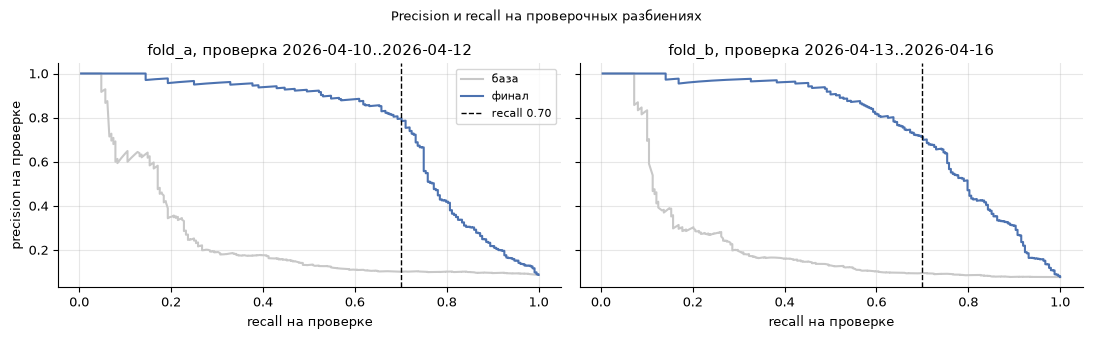

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for axis, fold in zip(axes, scripts.FOLDS):
    for label, name, color in [('база', 'quickstart__raw', '#c8c8c8'),
                               ('финал', FINAL, '#4c72b0')]:
        part = RUNS[name]['predictions']
        part = part[part['fold'] == fold]
        precision, recall = pr_curve(part['target'], part['score'])
        axis.plot(recall, precision, color=color, lw=1.5, label=label)
    axis.axvline(scripts.TARGET_RECALL, color='black', ls='--', lw=1, label='recall 0.70')
    first, last = scripts.FOLDS[fold]['valid']
    axis.set(xlabel='recall на проверке', title=f'{fold}, проверка {first}..{last}')
axes[0].set_ylabel('precision на проверке')
axes[0].legend(fontsize=8)
figure.suptitle('Precision и recall на проверочных разбиениях', fontsize=9)
plt.tight_layout()
plt.show()

У базы precision падает к доле ботов уже при recall 0.2. Максимальная precision при recall не ниже 0.70 у финала составляет 0.7960 и 0.7131, при дальнейшем росте recall precision быстро снижается

## Итог

Финал это 62 признака и среднее вероятностей трёх CatBoost с seed 0, 17 и 42: глубина 6, 1500 итераций, learning rate 0.03, l2 10. Метрика 0.7960 и 0.7131, среднее 0.7546 против 0.0995 у базы quickstart

Смесь дала 0.7653 по среднему, но ухудшила `fold_a`, поэтому оставил три CatBoost

Признаки и параметры выбирал на этих же двух разбиениях, поэтому на скрытой неделе качество может быть ниже. Обучение на полном train и создание `submission.csv` находятся в `solution.ipynb`

In [23]:
journal = tracking.export_runs([run['run_id'] for run in RUNS.values()])
journal[['name', 'model', 'n_features', 'seeds', 'weight_scheme', 'fold_a', 'fold_b',
         'mean', 'train_seconds']].round(4)

,name,model,n_features,seeds,weight_scheme,fold_a,fold_b,mean,train_seconds
304,quickstart__raw,RandomForestClassifier,2,0,нет,0.1035,0.0954,0.0995,1.0964
305,quickstart__clean,RandomForestClassifier,2,0,нет,0.1021,0.0921,0.0971,1.0763
306,forest__composition,RandomForestClassifier,20,0,нет,0.1616,0.1645,0.1631,2.4428
307,forest__diversity,RandomForestClassifier,12,0,нет,0.2005,0.2237,0.2121,2.5968
308,forest__rhythm,RandomForestClassifier,7,0,нет,0.2287,0.2475,0.2381,2.5924
309,forest__age,RandomForestClassifier,3,0,нет,0.1321,0.1070,0.1196,1.5579
310,forest__client,RandomForestClassifier,10,0,нет,0.1159,0.1021,0.1090,1.3407
311,forest__pointer,RandomForestClassifier,5,0,нет,0.2070,0.1982,0.2026,1.5150
312,forest__all-families,RandomForestClassifier,47,0,нет,0.6250,0.5819,0.6035,4.8392
313,catboost__depth6,CatBoostClassifier,47,0,нет,0.7407,0.6544,0.6976,4.3002
